# Equações Autônomas e Dinâmica Populacional

No capítulo de classificação, vimos rapidamente que uma equação de primeira ordem é **autônoma** quando pode ser escrita como $y'=f(y)$ — o lado direito não depende explicitamente de $t$.

Nesta aula, vamos explorar essas equações a fundo, no contexto de dinâmica populacional, e descobrir algo notável: é possível entender o comportamento qualitativo das soluções **sem resolver a equação**, só olhando para o seu lado direito.

## Crescimento exponencial: o modelo de Malthus

A hipótese mais simples sobre o crescimento de uma população $y(t)$ é que sua taxa de variação é proporcional ao valor atual — já vimos essa equação bem no início do curso, com outro nome:

$$
\frac{dy}{dt} = ry, \qquad y(0)=y_0,
$$

com solução $y(t) = y_0e^{rt}$.

Aqui $r$ é chamada de **taxa de crescimento** (se $r>0$) ou de **declínio** (se $r<0$).

Esse é o modelo de **Malthus**, e ele prevê crescimento exponencial *para sempre* — o que, na prática, não pode ser verdade: mais cedo ou mais tarde, espaço, comida ou outros recursos limitados vão reduzir essa taxa de crescimento.

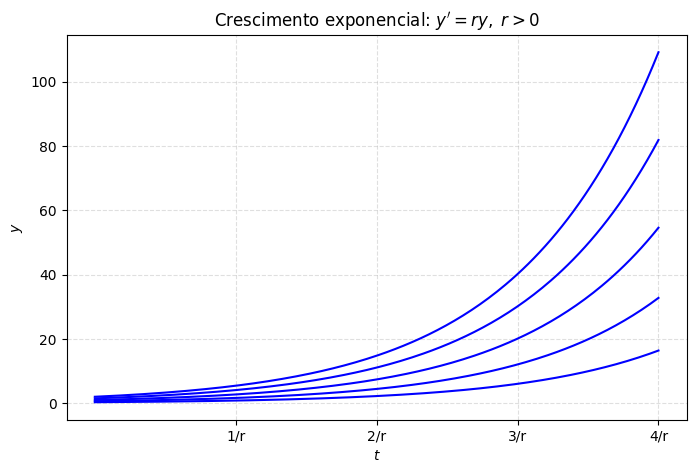

In [1]:
import numpy as np
import matplotlib.pyplot as plt

r_m = 0.4
t = np.linspace(0, 4/r_m, 200)

plt.figure(figsize=(8, 5))
for y0 in [0.3, 0.6, 1, 1.5, 2]:
    plt.plot(t, y0*np.exp(r_m*t), 'b')

plt.title(r"Crescimento exponencial: $y' = ry,\ r>0$")
plt.xlabel("$t$"); plt.ylabel("$y$")
plt.xticks([1/r_m, 2/r_m, 3/r_m, 4/r_m], ['1/r', '2/r', '3/r', '4/r'])
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## O crescimento logístico (Verhulst)

A ideia para consertar o modelo de Malthus é deixar a taxa de crescimento depender da própria população: grande quando $y$ é pequeno (a espécie tem espaço e recursos de sobra), e cada vez menor — até ficar negativa — conforme $y$ cresce e os recursos escasseiam.

Trocamos a constante $r$ por uma função $h(y)$:

$$
\frac{dy}{dt} = h(y)\,y.
$$

A escolha mais simples de $h(y)$ com esse comportamento é uma reta decrescente, $h(y) = r - ay$ (com $r,a>0$).

Substituindo:

$$
\frac{dy}{dt} = (r-ay)y,
$$

ou, escrevendo $K=r/a$ (forma equivalente, mas mais fácil de interpretar):

$$
\frac{dy}{dt} = r\left(1-\frac{y}{K}\right)y.
$$

Essa é a **equação logística** (ou de Verhulst).

Aqui $r$ é a **taxa de crescimento intrínseca** (a taxa quando $y$ é pequeno, sem nenhum fator limitante), e $K$ é a **capacidade de suporte** — o tamanho populacional máximo que o ambiente consegue sustentar.

### Resolvendo a equação logística por separação de variáveis

Vamos resolver

$$
\frac{dy}{dt} = r\left(1-\frac{y}{K}\right)y, \qquad y(0)=y_0,
$$

supondo, por enquanto, que $y\neq 0$ e $y\neq K$ (voltamos a esses dois casos daqui a pouco). Separando as variáveis:

$$
\frac{dy}{(1-y/K)\,y} = r\,dt.
$$

O lado esquerdo não é imediato de integrar do jeito que está, mas uma **decomposição em frações parciais** (uma técnica de Cálculo 2) simplifica bastante:

$$
\frac{1}{(1-y/K)\,y} = \frac{1}{y} + \frac{1/K}{1-y/K}.
$$

(Confira: colocando no mesmo denominador, os dois lados batem.)

Substituindo e integrando:

$$
\int\left(\frac{1}{y} + \frac{1/K}{1-y/K}\right)dy = \int r\,dt \quad\Longrightarrow\quad \ln|y| - \ln\left|1-\frac{y}{K}\right| = rt + c.
$$

Combinando os logaritmos e aplicando a exponencial dos dois lados:

$$
\frac{y}{1-y/K} = C\,e^{rt}.
$$

Usando a condição inicial $y(0)=y_0$ para achar $C = \dfrac{y_0}{1-y_0/K}$, e isolando $y$ depois de um pouco de álgebra, chegamos à solução:

$$
y(t) = \frac{y_0 K}{y_0 + (K-y_0)e^{-rt}}.
$$

(É um bom exercício conferir essa álgebra — ou deixar o Python verificar para você, como faremos a seguir.)

Repare que essa fórmula também vale, por coincidência feliz, para os casos $y_0=0$ e $y_0=K$ que tínhamos deixado de fora: ela dá exatamente $y(t)\equiv 0$ e $y(t)\equiv K$.

In [2]:
import sympy as sp

t_s, r_s, K_s, y0_s = sp.symbols('t r K y0', positive=True)

y_s = y0_s*K_s / (y0_s + (K_s - y0_s)*sp.exp(-r_s*t_s))

lado_esquerdo = sp.diff(y_s, t_s)
lado_direito = r_s*(1 - y_s/K_s)*y_s

print("y'(t) - r(1-y/K)y =", sp.simplify(lado_esquerdo - lado_direito))

y'(t) - r(1-y/K)y = 0


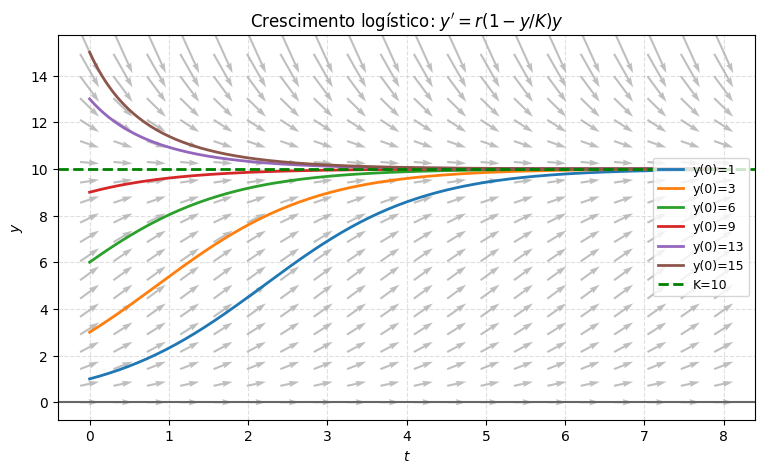

In [3]:
r_, K_ = 1.0, 10.0

def y_logistica(t, y0):
    return y0*K_ / (y0 + (K_ - y0)*np.exp(-r_*t))

def f_log(t, y):
    return r_*(1 - y/K_)*y

t_grid = np.linspace(0, 8, 20)
y_grid = np.linspace(0, 15, 20)
T, Y = np.meshgrid(t_grid, y_grid)
dt_step = (8 - 0)/20*0.6
dT = np.ones(T.shape)*dt_step
dV = f_log(T, Y)*dt_step

t = np.linspace(0, 8, 200)

plt.figure(figsize=(9, 5))
plt.quiver(T, Y, dT, dV, color='gray', alpha=0.5, pivot='mid',
           angles='xy', scale_units='xy', scale=1)

for y0 in [1, 3, 6, 9, 13, 15]:
    plt.plot(t, y_logistica(t, y0), linewidth=2, label=f'y(0)={y0}')

plt.axhline(K_, color='green', linestyle='--', linewidth=2, label=f'K={K_:g}')
plt.axhline(0, color='0.4', linewidth=1.5)
plt.title(r"Crescimento logístico: $y' = r(1-y/K)y$")
plt.xlabel("$t$"); plt.ylabel("$y$")
plt.legend(loc='center right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

### Exemplo: a biomassa de linguado gigante no Oceano Pacífico

O modelo logístico já foi usado para descrever o crescimento da biomassa de linguado gigante numa região do Oceano Pacífico, com parâmetros estimados $r=0{,}71$/ano e $K=80{,}5\times10^6$ kg. Partindo de $y_0=0{,}25K$, quanto vale a biomassa dois anos depois? E em que instante ela atinge $75\%$ da capacidade de suporte?

Dá para isolar $t$ algebricamente na fórmula (como o Boyce faz), mas vamos aproveitar e deixar o Python resolver isso numericamente para a gente:

y(2) = 4.666e+07 kg  (~46.7 milhões de kg)
tau = 3.095 anos


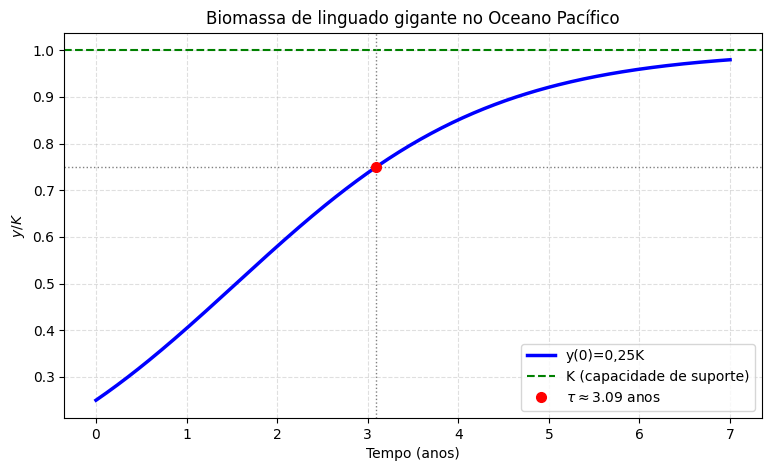

In [4]:
from scipy.optimize import brentq

r_h, K_h = 0.71, 80.5e6
y0_h = 0.25*K_h

def y_h(t):
    return y0_h*K_h / (y0_h + (K_h - y0_h)*np.exp(-r_h*t))

print(f"y(2) = {y_h(2):.3e} kg  (~{y_h(2)/1e6:.1f} milhões de kg)")

tau = brentq(lambda t: y_h(t) - 0.75*K_h, 0, 10)
print(f"tau = {tau:.3f} anos")

t = np.linspace(0, 7, 300)
plt.figure(figsize=(9, 5))
plt.plot(t, y_h(t)/K_h, 'b', linewidth=2.5, label='y(0)=0,25K')
plt.axhline(1, color='green', linestyle='--', label='K (capacidade de suporte)')
plt.axhline(0.75, color='0.5', linestyle=':', linewidth=1)
plt.axvline(tau, color='0.5', linestyle=':', linewidth=1)
plt.plot(tau, 0.75, 'ro', markersize=7, label=fr'$\tau\approx{tau:.2f}$ anos')
plt.title("Biomassa de linguado gigante no Oceano Pacífico")
plt.xlabel("Tempo (anos)")
plt.ylabel("$y/K$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## Análise geométrica: pontos de equilíbrio e a reta de fase

Repare que o gráfico da solução geral, lá em cima, já contém a resposta: para qualquer $y_0>0$, a solução converge para $K$; as retas $y=0$ e $y=K$ nunca são cruzadas por nenhuma outra curva. Será que dava para prever esse comportamento **sem resolver a equação**, só olhando para ela?

A resposta é sim — e a ideia é surpreendentemente simples. Como a equação é autônoma, $y'=f(y)$, o valor de $f(y)$ (a inclinação) depende só da altura $y$, não do instante $t$. Então basta estudar o **gráfico de $f(y)$ em função de $y$** para saber tudo sobre o comportamento qualitativo das soluções — sem integrar nada!

**Pontos de equilíbrio (ou pontos críticos).** São os valores de $y$ onde $f(y)=0$ — ali, $y'=0$, então a função constante $y(t)\equiv y^*$ é uma solução (uma **solução de equilíbrio**). Para a equação logística, $f(y)=r(1-y/K)y=0$ dá $y=0$ e $y=K$ — exatamente as duas retas horizontais que vimos no gráfico.

Fora dos pontos de equilíbrio, o sinal de $f(y)$ diz se $y$ está crescendo ou decrescendo:

* Onde $f(y)>0$, temos $y'>0$: $y$ cresce.
* Onde $f(y)<0$, temos $y'<0$: $y$ decresce.

Isso é tudo que precisamos! Vamos visualizar o gráfico de $f(y)$, com setas indicando essa direção de crescimento/decrescimento, e também a versão vertical dessa mesma informação — o eixo $y$ sozinho, chamado de **reta de fase**:

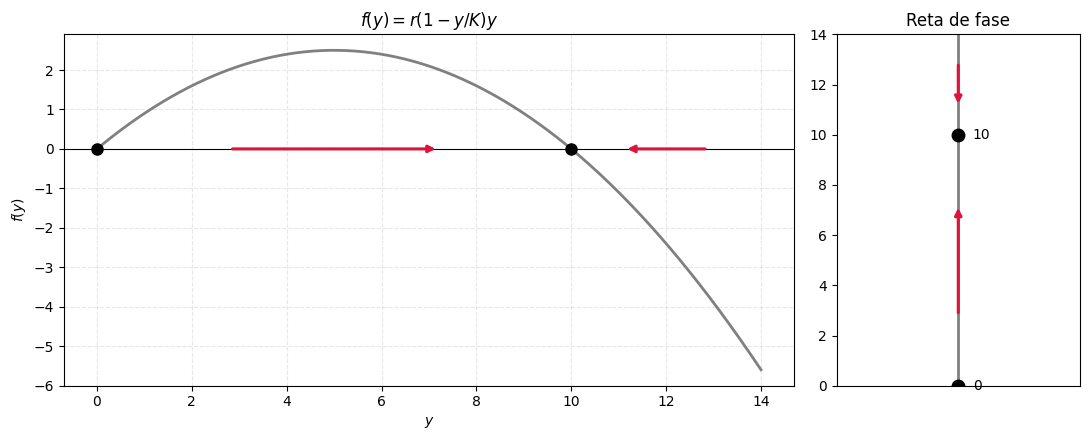

In [5]:
def plot_fy_e_reta_de_fase(f, y_min, y_max, equilibrios, titulo):
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={'width_ratios': [3, 1]})

    y = np.linspace(y_min, y_max, 400)
    axs[0].plot(y, f(y), color='gray', linewidth=2)
    axs[0].axhline(0, color='black', linewidth=0.8)
    for eq in equilibrios:
        axs[0].plot(eq, 0, 'ko', markersize=8, zorder=5)
    axs[0].set_xlabel("$y$"); axs[0].set_ylabel("$f(y)$")
    axs[0].set_title(titulo)
    axs[0].grid(True, linestyle='--', alpha=0.3)

    # pontos que dividem o domínio em intervalos: bordas + equilíbrios
    pts = sorted(equilibrios)
    if y_min < pts[0]:
        pts = [y_min] + pts
    if y_max > pts[-1]:
        pts = pts + [y_max]

    axs[1].vlines(0, y_min, y_max, color='gray', linewidth=2)
    for eq in equilibrios:
        axs[1].plot(0, eq, 'ko', markersize=9, zorder=5)
        axs[1].annotate(f'{eq:g}', xy=(0.12, eq), va='center', fontsize=10)
    axs[1].set_xlim(-1, 1)
    axs[1].set_ylim(y_min, y_max)
    axs[1].set_xticks([])
    axs[1].set_title("Reta de fase")

    for i in range(len(pts)-1):
        a, b = pts[i], pts[i+1]
        mid = (a+b)/2
        sinal = np.sign(f(np.array([mid]))[0])
        halflen = 0.22*(b-a)

        dx = halflen*sinal
        axs[0].annotate('', xy=(mid+dx, 0), xytext=(mid-dx, 0),
                         arrowprops=dict(arrowstyle='-|>', color='crimson', lw=2.2))

        dy = halflen*sinal
        axs[1].annotate('', xy=(0, mid+dy), xytext=(0, mid-dy),
                         arrowprops=dict(arrowstyle='-|>', color='crimson', lw=2.2))

    plt.tight_layout()
    plt.show()


def f_log_y(y):
    return r_*(1 - y/K_)*y

plot_fy_e_reta_de_fase(f_log_y, 0, 14, [0, K_], r"$f(y)=r(1-y/K)y$")

No gráfico da esquerda, a parábola cruza o eixo horizontal exatamente nos pontos de equilíbrio $y=0$ e $y=K$; entre eles, $f(y)>0$ (seta para a direita — $y$ cresce); acima de $K$, $f(y)<0$ (seta para a esquerda — $y$ decresce). Na reta de fase (direita), a mesma informação aparece de forma ainda mais direta: as setas por perto de $K$ **convergem** para ele, e as setas por perto de $0$ **se afastam** dele.

Isso define os dois conceitos centrais desta aula:

* **Equilíbrio assintoticamente estável**: soluções que começam perto dele tendem a ele quando $t\to\infty$. Aqui, $y=K$.
* **Equilíbrio instável**: soluções que começam perto dele se afastam. Aqui, $y=0$.

Ou seja: por menor que seja a população inicial (desde que positiva), ela cresce e se aproxima de $K$; e se a população começar acima de $K$, ela decresce até $K$. Tudo isso, **sem resolver a equação diferencial** — só olhando para o sinal de $f(y)$!

Vale registrar um ponto sutil: mesmo um termo não linear "pequeno" (o $-ay^2$ que diferencia a equação logística da exponencial pura) muda completamente o destino da solução no longo prazo — de crescimento ilimitado para uma acomodação em $K$. É um bom lembrete de por que a distinção linear/não linear, que vimos lá na aula de classificação, importa tanto.

## Um limiar crítico

Considere agora uma equação parecida, mas com um sinal de menos a mais:

$$
\frac{dy}{dt} = -r\left(1-\frac{y}{T}\right)y, \qquad r>0,\ T>0.
$$

Os pontos de equilíbrio continuam sendo as raízes do lado direito: $y=0$ e $y=T$. Mas o sinal trocado muda tudo:

* Para $0<y<T$: $-r(1-y/T)y < 0$, então $y$ **decresce** (em direção a $0$).
* Para $y>T$: $-r(1-y/T)y > 0$, então $y$ **cresce** (se afastando de $T$).

Ou seja, os papéis se inverteram por completo em relação ao caso logístico: agora $y=0$ é **assintoticamente estável**, e $y=T$ é **instável**. $T$ funciona como um **limiar**: populações que começam abaixo dele encolhem até a extinção; populações que começam acima dele crescem sem parar.

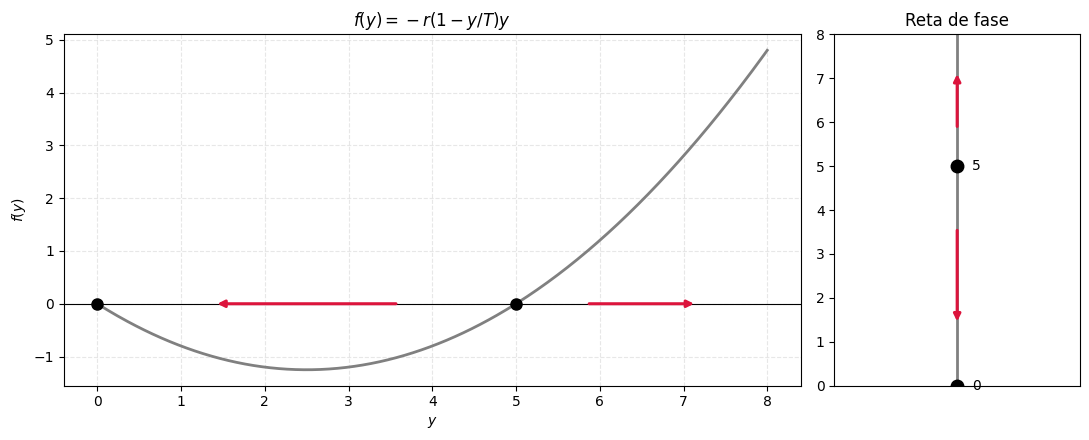

In [6]:
r_T, T_ = 1.0, 5.0

def f_thr_y(y):
    return -r_T*(1 - y/T_)*y

plot_fy_e_reta_de_fase(f_thr_y, 0, 8, [0, T_], r"$f(y)=-r(1-y/T)y$")

Limiares críticos como esse aparecem em vários contextos além da biologia. Em mecânica dos fluidos, por exemplo, pequenas perturbações num escoamento laminar costumam seguir uma equação parecida com essa: abaixo de uma certa **amplitude crítica** $T$, a perturbação se dissipa e o escoamento permanece laminar; acima dela, a perturbação cresce e o escoamento se torna turbulento.

Podemos resolver essa equação exatamente do mesmo jeito que a logística (é separável!). Na verdade, repare que a equação do limiar sai da equação logística trocando $K\to T$ e $r\to -r$ — então podemos fazer essa mesma substituição direto na solução que já temos:

$$
y(t) = \frac{y_0 T}{y_0 + (T-y_0)e^{rt}}.
$$

Repare no expoente **positivo**: se $y_0>T$, o termo $(T-y_0)e^{rt}$ é negativo e cresce em módulo sem parar — o denominador zera num instante finito $t^*$, e a população **explode em tempo finito** (não só quando $t\to\infty$, como no crescimento exponencial comum)! Vamos visualizar:

In [7]:
t_s2, r_s2, T_s2, y0_s2 = sp.symbols('t r T y0', positive=True)

y_thr_s = y0_s2*T_s2 / (y0_s2 + (T_s2 - y0_s2)*sp.exp(r_s2*t_s2))

lado_esquerdo2 = sp.diff(y_thr_s, t_s2)
lado_direito2 = -r_s2*(1 - y_thr_s/T_s2)*y_thr_s

print("y'(t) - [-r(1-y/T)y] =", sp.simplify(lado_esquerdo2 - lado_direito2))

y'(t) - [-r(1-y/T)y] = 0


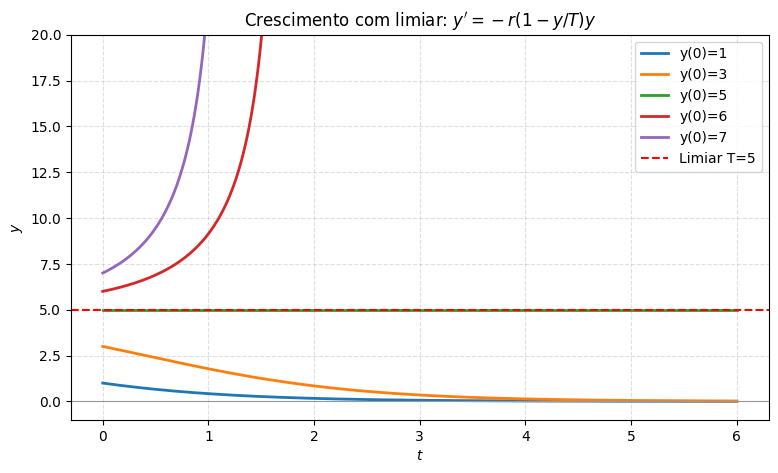

In [8]:
def y_limiar(t, y0):
    denom = y0 + (T_ - y0)*np.exp(r_T*t)
    y = y0*T_/denom
    return np.where(denom > 0, y, np.nan)

t = np.linspace(0, 6, 400)

plt.figure(figsize=(9, 5))
for y0 in [1, 3, 5, 6, 7]:
    plt.plot(t, y_limiar(t, y0), linewidth=2, label=f'y(0)={y0}')

plt.axhline(T_, color='red', linestyle='--', label=f'Limiar T={T_:g}')
plt.axhline(0, color='0.6', linewidth=0.8)
plt.ylim(-1, 20)
plt.title(r"Crescimento com limiar: $y' = -r(1-y/T)y$")
plt.xlabel("$t$"); plt.ylabel("$y$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## Crescimento logístico com limiar

O modelo de limiar da seção anterior tem um problema: ele prevê crescimento *ilimitado* para $y_0>T$, o que não é realista — toda população real esbarra, cedo ou tarde, numa capacidade de suporte. A correção natural é combinar os dois efeitos, o limiar **e** a capacidade de suporte, numa equação só:

$$
\frac{dy}{dt} = -r\left(1-\frac{y}{T}\right)\left(1-\frac{y}{K}\right)y, \qquad r>0,\ 0<T<K.
$$

Agora temos **três** pontos de equilíbrio: $y=0$, $y=T$ e $y=K$. Analisando o sinal do lado direito em cada faixa:

* $0<y<T$: o lado direito é negativo — $y$ decresce (rumo a $0$).
* $T<y<K$: o lado direito é positivo — $y$ cresce (rumo a $K$).
* $y>K$: o lado direito é negativo — $y$ decresce (rumo a $K$).

Então $y=0$ e $y=K$ são assintoticamente estáveis, e $y=T$ (o limiar) é instável, espremido entre os dois:

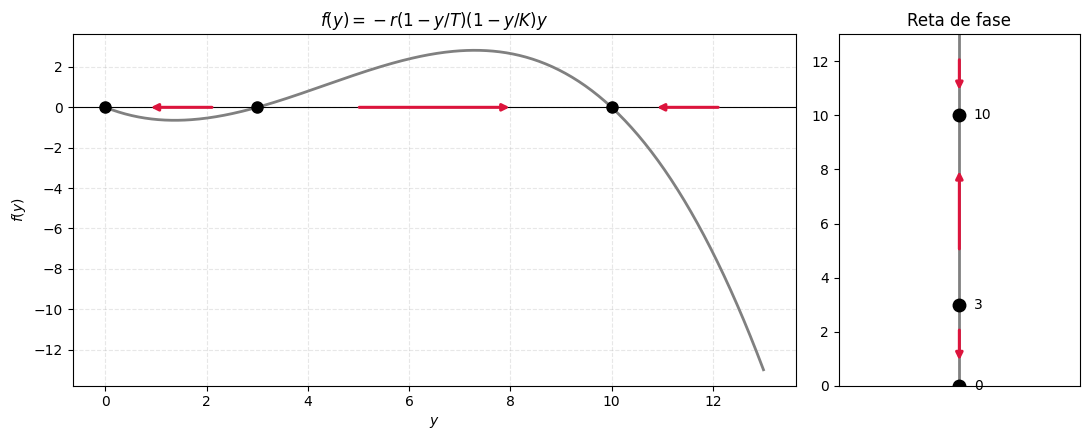

In [9]:
r_c, T_c, K_c = 1.0, 3.0, 10.0

def f_comb_y(y):
    return -r_c*(1 - y/T_c)*(1 - y/K_c)*y

plot_fy_e_reta_de_fase(f_comb_y, 0, 13, [0, T_c, K_c], r"$f(y)=-r(1-y/T)(1-y/K)y$")

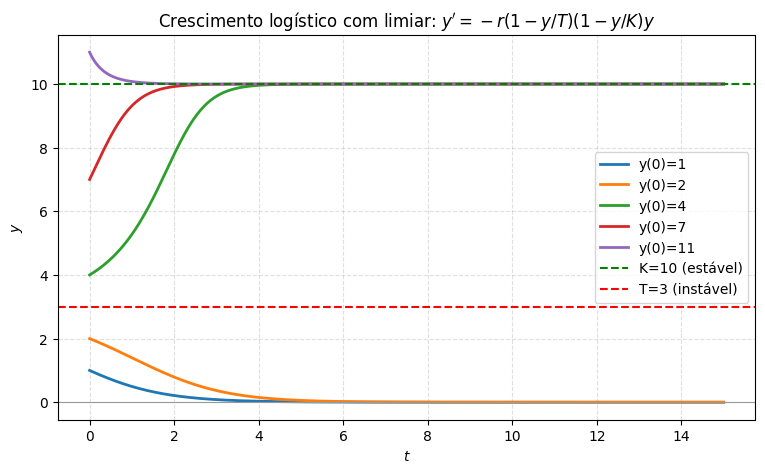

In [10]:
from scipy.integrate import odeint

def f_comb(y, t):
    return -r_c*(1 - y/T_c)*(1 - y/K_c)*y

t = np.linspace(0, 15, 400)

plt.figure(figsize=(9, 5))
for y0 in [1, 2, 4, 7, 11]:
    sol = odeint(f_comb, y0, t)
    plt.plot(t, sol[:, 0], linewidth=2, label=f'y(0)={y0}')

plt.axhline(K_c, color='green', linestyle='--', label=f'K={K_c:g} (estável)')
plt.axhline(T_c, color='red', linestyle='--', label=f'T={T_c:g} (instável)')
plt.axhline(0, color='0.6', linewidth=0.8)
plt.title(r"Crescimento logístico com limiar: $y'=-r(1-y/T)(1-y/K)y$")
plt.xlabel("$t$"); plt.ylabel("$y$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Repare que, dessa vez, não escrevemos uma fórmula fechada para $y(t)$ — a decomposição em frações parciais fica bem mais trabalhosa com três raízes, e usamos integração numérica (`odeint`) para desenhar as curvas. Isso ilustra bem o valor da abordagem geométrica: mesmo sem uma fórmula explícita, sabíamos exatamente qual seria o formato qualitativo das soluções antes mesmo de calcular qualquer coisa.

Esse tipo de modelo (com limiar) já foi usado para descrever a extinção do **pombo-passageiro** nos Estados Unidos. Até o final do século XIX, a espécie existia em quantidades imensas — bilhões de indivíduos. Mas ela só conseguia se reproduzir com sucesso quando presente em grandes concentrações (um limiar $T$ relativamente alto). A caça intensa reduziu a densidade local da espécie abaixo desse limiar, mesmo com um número absoluto de indivíduos ainda grande — e a população, presa no lado errado do limiar, entrou em colapso. O último pombo-passageiro morreu em 1914. É um exemplo real (e triste) de como um limiar crítico, e não só o tamanho absoluto da população, pode decidir o destino de uma espécie.

## O que vem a seguir

Com isso, fechamos o estudo das equações de primeira ordem: lineares (fator integrante), separáveis (separação de variáveis) e autônomas (reta de fase e estabilidade) — três ferramentas complementares, cada uma com seu domínio de aplicação.

Vamos guardar essa ideia de reta de fase e estabilidade — ela vai reaparecer, de um jeito mais rico, quando estudarmos **sistemas** de equações lineares mais adiante no curso. Por enquanto, seguimos para o próximo grande tema: equações diferenciais de **segunda ordem**, que aparecem naturalmente em sistemas mecânicos e elétricos.